In [1]:
import numpy as np
import os 
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

#TODO : fix finding length 

WORKING_DIR="/Users/dlakhdar/physics/copy_repos/natural-quantization/data/experiment_data"
binomial_error = lambda p,N : (p*(1-p)/N)**(1/2)

def split_chunks(lst, n):
    """Split a list into chunks of size n."""
    for i in range(0, len(lst), n):
        yield lst[i:i + n]
        
# 3) Define a small recursive converter that turns any np.generic into a native Python number:
def convert_to_native(obj):
    if isinstance(obj, np.generic):
        return obj.item()   # e.g. np.int64 -> Python int; np.float64 -> Python float
    elif isinstance(obj, list):
        return [convert_to_native(x) for x in obj]
    elif isinstance(obj, tuple):
        return tuple(convert_to_native(x) for x in obj)
    else:
        return obj
    

def analysis(working_dir,experiment_dir,file_index: (tuple | bool)=None,true_label:int=2,n_samples=96):

 
    files = os.listdir(os.path.join(working_dir,experiment_dir))
    # files = [os.path.join(working_dir,experiment_dir,f"run{i}", file) for file in files]
    files.sort()

    if file_index is not None:
        start,end = file_index[0],file_index[1]
        files = files[start:end]

    data = []
    for file in files:
        file = os.path.join(working_dir, experiment_dir, file)
        with open(file, "r") as f:
            text = f.read()  # disable built-ins for safety)                    )
            # namespace = {"np": np}
            evaluated_data =  eval(
                    text,
                    {"__builtins__": None},   # disable built-ins for safety
                    {"array": np.array}       # map the name 'array' to numpy's array constructor
                ) if "array" in text else eval(text)
            converted = convert_to_native(evaluated_data)
            data.append(converted)

    data = sum(data, []) 
    new_data = []

    for d in data:
        new_data.append(d[-1])

    accuracies = []
    for i,digit in enumerate(new_data):
        for da in digit:
            accuracies.append(np.mean(np.array(da)==true_label))


    errors=binomial_error(np.array(accuracies), 96)

    return accuracies, errors
    
    # plt.plot(noises,acc,label="validation rate: NY",marker='o')
    # plt.plot(noises,bad_acc,label="simulated validation rate: YY",marker='x')


NY_classical_noises = [0,5,10,20,50,100]
NY_classical_accuracy,NY_classical_error = analysis(
                                 WORKING_DIR,
                                 "noise/single_qubit/run1",
                                 true_label=2)


NY_quantum_noises = [0,10,20,50,100]

NY_quantum_accuracy,NY_quantum_error = analysis(
                                 WORKING_DIR, 
                                 "noise/single_qubit/run3",
                                 file_index=(3,8),
                                 true_label=2)


YY_quantum_noises = [0,10,20,50,100]

YY_quantum_accuracy,YY_quantum_error = analysis(WORKING_DIR,
                                                "noise/single_qubit/run4",
                                                true_label=7)

YY_classical_noises = [0,5,10,20,50,100]
YY_classical_accuracy,YY_classical_error = analysis(WORKING_DIR,
                                                "noise/single_qubit/run5",
                                                true_label=7)

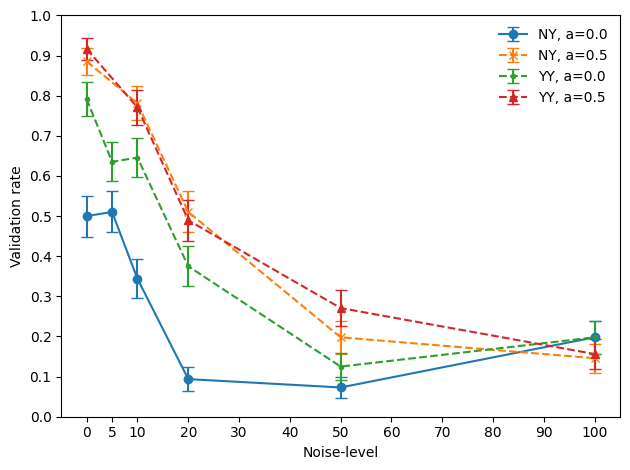

In [358]:

# plt.figure(figsize=(15,8))
# plt.title(r"Validation vrs. Noise-Level: $\hat{U}$=$R_x(\pi/2)$ , 96 Samples on Eagle Processor")
# plt.plot(noises,acc,label="validation rate: NY",marker='o')
# plt.plot(noises,bad_acc,label="simulated validation rate: YY",marker='x')

# plt.scatter(As,accuracies,color="orange")
plt.errorbar(x=NY_classical_noises,y=NY_classical_accuracy,yerr=NY_classical_error,fmt='o-',capsize=4,barsabove=False,label="NY, a=0.0")

plt.errorbar(x=NY_quantum_noises,y=NY_quantum_accuracy,yerr=NY_quantum_error,fmt='x--',capsize=4,barsabove=False,label="NY, a=0.5")

plt.errorbar(x=YY_classical_noises,y=YY_classical_accuracy,yerr=YY_classical_error,fmt='.--',capsize=4,barsabove=False,label="YY, a=0.0")
plt.errorbar(x=YY_quantum_noises,y=YY_quantum_accuracy,yerr=YY_quantum_error,fmt='^--',capsize=4,barsabove=False,label="YY, a=0.5")
# plt.plot(0.0,.48,'ro',label="validation on quantum device",markersize=5)
plt.xlabel(r"Noise-level")
plt.legend(frameon=False)
# plt.grid()
plt.xticks([0,5,10,20,30,40,50,60,70,80,90,100])
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.ylabel(r"Validation rate")
plt.tight_layout()



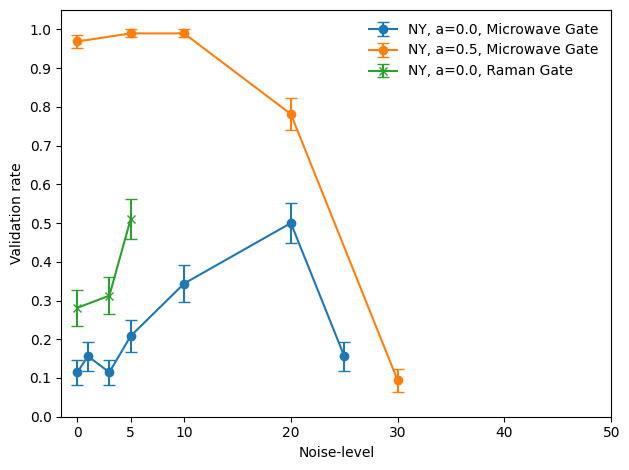

In [2]:

# plt.figure(figsize=(15,8))
# plt.title(r"Validation vrs. Noise-Level: $\hat{U}$=$R_x(\pi/2)$ , 96 Samples on Eagle Processor")
# plt.plot(noises,acc,label="validation rate: NY",marker='o')
# plt.plot(noises,bad_acc,label="simulated validation rate: YY",marker='x')

trapped_ion_NY_classical_num_pairs   = [0, 1, 3, 5, 10, 20, 25]
trapped_ion_NY_classical_accuracy  = [11/96, 15/96, 11/96, 20/96, 33/96, 48/96, 15/96]
trapped_ion_NY_classical_error = [binomial_error(p,96) for p in trapped_ion_NY_classical_accuracy]


trapped_ion_NY_quantum_num_pairs  = [0, 5, 10, 20, 30]
trapped_ion_NY_quantum_accuracy = [93/96, 95/96, 95/96, 75/96, 9/96]
trapped_ion_NY_quantum_error = [binomial_error(p,96) for p in trapped_ion_NY_quantum_accuracy]

trapped_ion_NY_laser_num_pairs = [0,3,5]
trapped_ion_NY_laser_accuracy = [27/96,30/96,49/96]
trapped_ion_NY_laser_error = [binomial_error(p,96) for p in trapped_ion_NY_laser_accuracy]

trapped_ion_YY_classical_num_pairs= [0,20,25,50]
trapped_ion_YY_classical_accuracy = [90/96,92/96,49/96, 12/96]
trapped_ion_YY_classical_error = [binomial_error(p,96) for p in trapped_ion_YY_classical_accuracy]

trapped_ion_YY_quantum_num_pairs = [0,20,25,50]
trapped_ion_YY_quantum_accuracy = [95/96,96/96,65/96, 14/96]
trapped_ion_YY_quantum_error = [binomial_error(p,96) for p in trapped_ion_YY_quantum_accuracy]

# plt.scatter(As,accuracies,color="orange")
plt.errorbar(x=trapped_ion_NY_classical_num_pairs,y=trapped_ion_NY_classical_accuracy,yerr=trapped_ion_NY_classical_error,fmt='o-',capsize=4,barsabove=False,label="NY, a=0.0, Microwave Gate")

plt.errorbar(x=trapped_ion_NY_quantum_num_pairs,y=trapped_ion_NY_quantum_accuracy,yerr=trapped_ion_NY_quantum_error,fmt='o-',capsize=4,barsabove=False,label="NY, a=0.5, Microwave Gate")
plt.errorbar(x=trapped_ion_NY_laser_num_pairs,y=trapped_ion_NY_laser_accuracy,yerr=trapped_ion_NY_laser_error,fmt='x-',capsize=4,barsabove=False,label="NY, a=0.0, Raman Gate")



plt.xlabel(r"Noise-level")
plt.legend(frameon=False)
# plt.grid()
plt.xticks([0,5,10,20,30,40, 50])
plt.yticks(np.arange(0, 1.3, 0.1))
plt.ylim(0, 1.05)
plt.ylabel(r"Validation rate")
plt.tight_layout()


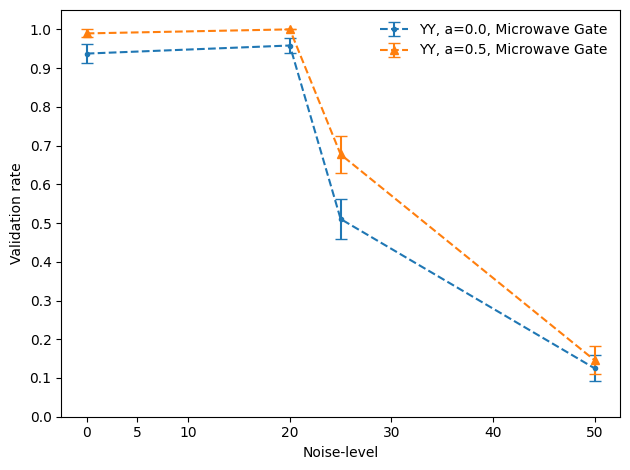

In [357]:
plt.errorbar(x=trapped_ion_YY_classical_num_pairs,y=trapped_ion_YY_classical_accuracy,yerr=trapped_ion_YY_classical_error,fmt='.--',capsize=4,barsabove=False,label="YY, a=0.0, Microwave Gate")
plt.errorbar(x=trapped_ion_YY_quantum_num_pairs,y=trapped_ion_YY_quantum_accuracy,yerr=trapped_ion_YY_quantum_error,fmt='^--',capsize=4,barsabove=False,label="YY, a=0.5, Microwave Gate")
# plt.plot(0.0,.48,'ro',label="validation on quantum device",markersize=5)
plt.xlabel(r"Noise-level")
plt.legend(frameon=False)
# plt.grid()
plt.xticks([0,5,10,20,30,40, 50])
plt.yticks(np.arange(0, 1.3, 0.1))
plt.ylim(0, 1.05)
plt.ylabel(r"Validation rate")
plt.tight_layout()

In [3]:
working_dir="/Users/dlakhdar/physics/copy_repos/natural-quantization"
experiment_dir="data/experiment_data/noise/two_qubit/simulation/run3"
files = os.listdir(os.path.join(working_dir,experiment_dir))
files = [os.path.join(working_dir,
                      experiment_dir, 
                      file) for file in files]
files.sort()
# if file_index is not None:
#     start,end = file_index[0],file_index[1]
#     files = files[start:end]
print(files)
data = []
for file in files:
    with open(file, "r") as f:
        text = f.read()  # disable built-ins for safety)                    )
            # namespace = {"np": np}
        evaluated_data =  eval(
                    text,
                    {"__builtins__": None},   # disable built-ins for safety
                    {"array": np.array}       # map the name 'array' to numpy's array constructor
                )  if "array" in text  else eval(text)
        converted = convert_to_native(evaluated_data)
        data.append(converted)



simulated_two_qubit_YY_quantum_accuracy, simulated_two_qubit_YY_classical_accuracy = [], []

for da in data:
    print(da[0])
    quantum_case, classical_case =da[1][-1], da[0][-1]
    simulated_two_qubit_YY_quantum_accuracy.append(np.mean(np.array(quantum_case)==7))
    simulated_two_qubit_YY_classical_accuracy.append(np.mean(np.array(classical_case)==7))

two_qubit_YY_quantum_error = binomial_error(np.array(simulated_two_qubit_YY_quantum_accuracy),96)
two_qubit_YY_classical_error = binomial_error(np.array(simulated_two_qubit_YY_classical_accuracy),96)
two_qubit_YY_quantum_error.tolist()

working_dir="/Users/dlakhdar/physics/copy_repos/natural-quantization"
experiment_dir="data/experiment_data/noise/two_qubit/simulation/run5"
files = os.listdir(os.path.join(working_dir,experiment_dir))
files = [os.path.join(working_dir,
                      experiment_dir, 
                      file) for file in files]
files.sort()
# if file_index is not None:
#     start,end = file_index[0],file_index[1]
#     files = files[start:end]
print(files)
data = []
for file in files:
    with open(file, "r") as f:
        text = f.read()  # disable built-ins for safety)                    )
            # namespace = {"np": np}
        evaluated_data =  eval(
                    text,
                    {"__builtins__": None},   # disable built-ins for safety
                    {"array": np.array}       # map the name 'array' to numpy's array constructor
                )  if "array" in text  else eval(text)
        converted = convert_to_native(evaluated_data)
        data.append(converted)



simulated_two_qubit_NY_quantum_accuracy, simulated_two_qubit_NY_classical_accuracy = [], []

for da in data:
    quantum_case, classical_case =da[1][-1], da[0][-1]
    simulated_two_qubit_NY_quantum_accuracy.append(np.mean(np.array(quantum_case)==2))
    simulated_two_qubit_NY_classical_accuracy.append(np.mean(np.array(classical_case)==2))

two_qubit_NY_quantum_error = binomial_error(np.array(simulated_two_qubit_NY_quantum_accuracy),96)
two_qubit_NY_classical_error = binomial_error(np.array(simulated_two_qubit_NY_classical_accuracy),96)

    # for d in data:
    #     new_data.append(d[-1])

    # accuracies = []
    # for i,digit in enumerate(new_data):
    #     for da in digit:
    #         accuracies.append(np.mean(np.array(da)==7))



['/Users/dlakhdar/physics/copy_repos/natural-quantization/data/experiment_data/noise/two_qubit/simulation/run3/2025-06-25_19:27:54.051084_index_0_noise_0_results.txt', '/Users/dlakhdar/physics/copy_repos/natural-quantization/data/experiment_data/noise/two_qubit/simulation/run3/2025-06-25_20:21:14.978043_index_0_noise_5_results.txt', '/Users/dlakhdar/physics/copy_repos/natural-quantization/data/experiment_data/noise/two_qubit/simulation/run3/2025-06-25_20:43:23.046216_index_0_noise_10_results.txt', '/Users/dlakhdar/physics/copy_repos/natural-quantization/data/experiment_data/noise/two_qubit/simulation/run3/2025-06-25_21:04:57.132350_index_0_noise_20_results.txt', '/Users/dlakhdar/physics/copy_repos/natural-quantization/data/experiment_data/noise/two_qubit/simulation/run3/2025-06-25_21:26:27.060999_index_0_noise_50_results.txt']
[0.0, 16, [[7, 7, 7, 7, 2, 2, 7, 9, 7, 7, 7, 7, 3, 7, 7, 7, 7, 7, 7, 3, 7, 2, 7, 7, 7, 7, 7, 7, 7, 7, 2, 7, 7, 2, 2, 7, 7, 2, 3, 7, 3, 7, 3, 1, 7, 7, 7, 7, 7, 2,

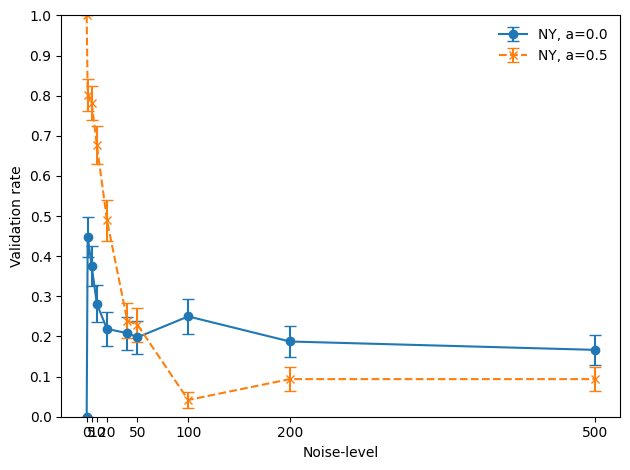

In [ ]:
# plt.scatter(As,accuracies,color="orange")


# plt.errorbar(x=[0,1,5,10,20,40,50],y=two_qubit_YY_classical_accuracy,yerr=two_qubit_NY_classical_error,fmt='o-',capsize=4,barsabove=False,label="NY, a=0.0")

# plt.errorbar(x=[0,1,5,10,20,40,50],y=two_qubit_YY_quantum_accuracy,yerr=two_qubit_NY_quantum_error,fmt='x--',capsize=4,barsabove=False,label="NY, a=0.5")

plt.errorbar(x=[0,1,5,10,20,40,50,100,200,500],y=simulated_two_qubit_NY_classical_accuracy,yerr=two_qubit_NY_classical_error,fmt='o-',capsize=4,barsabove=False,label="NY, a=0.0")

plt.errorbar(x=[0,1,5,10,20,40,50,100,200,500],y=simulated_two_qubit_NY_quantum_accuracy,yerr=two_qubit_NY_quantum_error,fmt='x--',capsize=4,barsabove=False,label="NY, a=0.5")

# plt.plot(0.0,.48,'ro',label="validation on quantum device",markersize=5)
plt.xlabel(r"Noise-level")
plt.legend(frameon=False)
# plt.grid()
plt.xticks([0,5,10,20,50,100,200,500])
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.ylabel(r"Validation rate")
plt.tight_layout()

In [334]:
working_dir="/Users/dlakhdar/physics/copy_repos/natural-quantization"
experiment_dir="data/experiment_data/noise/two_qubit/quantum/run3"
files = os.listdir(os.path.join(working_dir,experiment_dir))
files = [os.path.join(working_dir,
                      experiment_dir, 
                      file) for file in files]
files.sort()
# if file_index is not None:
#     start,end = file_index[0],file_index[1]
#     files = files[start:end]
print(files)
data = []
for file in files:
    with open(file, "r") as f:
        text = f.read()  # disable built-ins for safety)                    )
            # namespace = {"np": np}
        evaluated_data =  eval(
                    text,
                    {"__builtins__": None},   # disable built-ins for safety
                    {"array": np.array}       # map the name 'array' to numpy's array constructor
                )  if "array" in text  else eval(text)
        converted = convert_to_native(evaluated_data)
        data.append(converted)


# new_data = data[1:]
# new_data[1]=[new_data[0],new_data[1]]
# new_data=new_data[1:]
# working_dir="/Users/dlakhdar/physics/copy_repos/natural-quantization"
# experiment_dir="data/experiment_data/noise/two_qubit/simulation/run5"
# files = os.listdir(os.path.join(working_dir,experiment_dir))
# files = [os.path.join(working_dir,
#                       experiment_dir, 
#                       file) for file in files]
# files.sort()
# # if file_index is not None:
# #     start,end = file_index[0],file_index[1]
# #     files = files[start:end]
# print(files)
# data = []
# for file in files:
#     with open(file, "r") as f:
#         text = f.read()  # disable built-ins for safety)                    )
#             # namespace = {"np": np}
#         evaluated_data =  eval(
#                     text,
#                     {"__builtins__": None},   # disable built-ins for safety
#                     {"array": np.array}       # map the name 'array' to numpy's array constructor
#                 )  if "array" in text  else eval(text)
#         converted = convert_to_native(evaluated_data)
#         data.append(converted)


# print(data)
# two_qubit_NY_quantum_accuracy, two_qubit_NY_classical_accuracy = [], []

# for da in data:
#     quantum_case, classical_case =da[1][-1], da[0][-1]
#     two_qubit_NY_quantum_accuracy.append(np.mean(np.array(quantum_case)==2))
#     two_qubit_NY_classical_accuracy.append(np.mean(np.array(classical_case)==2))

# two_qubit_NY_quantum_error = binomial_error(np.array(two_qubit_NY_quantum_accuracy),96)
# two_qubit_NY_classical_error = binomial_error(np.array(two_qubit_NY_classical_accuracy),96)

    # for d in data:
    #     new_data.append(d[-1])

    # accuracies = []
    # for i,digit in enumerate(new_data):
    #     for da in digit:
    #         accuracies.append(np.mean(np.array(da)==7))



['/Users/dlakhdar/physics/copy_repos/natural-quantization/data/experiment_data/noise/two_qubit/quantum/run3/0000_index_6929_noise_0_results.txt', '/Users/dlakhdar/physics/copy_repos/natural-quantization/data/experiment_data/noise/two_qubit/quantum/run3/2025-06-27_17:40:41.374690_index_6929_noise_1_results.txt', '/Users/dlakhdar/physics/copy_repos/natural-quantization/data/experiment_data/noise/two_qubit/quantum/run3/2025-06-29_18:55:00.950382_index_6929_noise_5_results.txt', '/Users/dlakhdar/physics/copy_repos/natural-quantization/data/experiment_data/noise/two_qubit/quantum/run3/2025-06-29_19:11:21.268575_index_6929_noise_10_results.txt', '/Users/dlakhdar/physics/copy_repos/natural-quantization/data/experiment_data/noise/two_qubit/quantum/run3/2025-06-29_21:53:53.680348_index_6929_noise_20_results.txt', '/Users/dlakhdar/physics/copy_repos/natural-quantization/data/experiment_data/noise/two_qubit/quantum/run3/2025-06-29_22:12:40.676105_index_6929_noise_50_results.txt', '/Users/dlakhdar

In [4]:


two_qubit_NY_quantum_accuracy, two_qubit_NY_classical_accuracy = [], []

for da in data:
    print(da)
    quantum_case, classical_case = da[1][-1], da[0][-1]
    two_qubit_NY_quantum_accuracy.append(np.mean(np.array(quantum_case)==2))
    two_qubit_NY_classical_accuracy.append(np.mean(np.array(classical_case)==2))

two_qubit_NY_quantum_error = binomial_error(np.array(two_qubit_NY_quantum_accuracy),96)
two_qubit_NY_classical_error = binomial_error(np.array(two_qubit_NY_classical_accuracy),96)



[[0.0, 16, [[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]]], [0.5, 16, [[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]]]]
[[0.0, 16, [[1, 2, 2, 3, 2, 2, 8, 1, 3, 8, 2, 6, 1, 2, 2, 2, 2, 7, 7, 3, 3, 1, 2, 1, 3, 6, 2, 1, 2, 2, 2, 1, 2, 2, 2, 8, 7, 2, 8, 7, 2, 7, 8, 1, 8, 7, 2, 8, 3, 2, 2, 2, 8, 2, 2, 8, 8, 2, 2, 2, 2, 7, 2, 1, 7, 3, 2, 3, 1, 8, 5, 2, 3, 2, 1, 6, 2, 7, 1, 2, 3, 5, 5, 2, 5, 1, 5, 2, 8, 2, 2, 2, 2, 2, 2, 1]]], [0.5, 16, [[2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 5, 2, 7, 2, 2, 6, 2, 2, 2, 2, 2, 2,

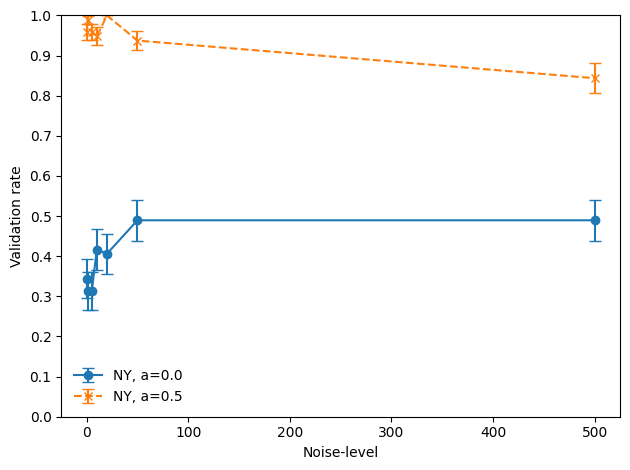

In [ ]:
# plt.scatter(As,accuracies,color="orange")


# plt.errorbar(x=[0,1,5,10,20,40,50],y=two_qubit_YY_classical_accuracy,yerr=two_qubit_NY_classical_error,fmt='o-',capsize=4,barsabove=False,label="NY, a=0.0")

# plt.errorbar(x=[0,1,5,10,20,40,50],y=two_qubit_YY_quantum_accuracy,yerr=two_qubit_NY_quantum_error,fmt='x--',capsize=4,barsabove=False,label="NY, a=0.5")

plt.errorbar(x=[0,1,5,10,20,50,500],y=two_qubit_NY_classical_accuracy,yerr=two_qubit_NY_classical_error,fmt='o-',capsize=4,barsabove=False,label="NY, a=0.0")

plt.errorbar(x=[0,1,5,10,20,50,500],y=two_qubit_NY_quantum_accuracy,yerr=two_qubit_NY_quantum_error,fmt='x--',capsize=4,barsabove=False,label="NY, a=0.5")

# plt.plot(0.0,.48,'ro',label="validation on quantum device",markersize=5)
plt.xlabel(r"Noise-level")
plt.legend(frameon=False)
# plt.grid()
# plt.xticks([0,,10,20,50])
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1.05)
plt.ylabel(r"Validation rate")
plt.tight_layout()

In [328]:
two_qubit_NY_quantum_error

array([0.        , 0.04066449, 0.04219232, 0.04772332, 0.05101996,
       0.04356307, 0.04289635, 0.02039469, 0.02974911, 0.02974911])

In [325]:
two_qubit_NY_classical_error

array([0.        , 0.05075342, 0.04941059, 0.04588805, 0.04219232,
       0.04144908, 0.04066449, 0.04419417, 0.03983609, 0.03803629])

In [491]:

# plt.figure(figsize=(15,8))
# plt.title(r"Validation vrs. Noise-Level: $\hat{U}$=$R_x(\pi/2)$ , 96 Samples on Eagle Processor")
# plt.plot(noises,acc,label="validation rate: NY",marker='o')
# plt.plot(noises,bad_acc,label="simulated validation rate: YY",marker='x')

# plt.scatter(As,accuracies,color="orange")
plt.errorbar(x=NY_classical_noises,y=NY_classical_accuracy,yerr=NY_classical_error,fmt='o-',capsize=4,barsabove=False,label="NY, a=0.0")

plt.errorbar(x=NY_quantum_noises,y=NY_quantum_accuracy,yerr=NY_quantum_error,fmt='x--',capsize=4,barsabove=False,label="NY, a=0.5")

plt.errorbar(x=YY_classical_noises,y=YY_classical_accuracy,yerr=YY_classical_error,fmt='.--',capsize=4,barsabove=False,label="YY, a=0.0")
plt.errorbar(x=YY_quantum_noises,y=YY_quantum_accuracy,yerr=YY_quantum_error,fmt='^--',capsize=4,barsabove=False,label="YY, a=0.5")
# plt.plot(0.0,.48,'ro',label="validation on quantum device",markersize=5)
plt.xlabel(r"Noise-level")
plt.legend(frameon=False)
# plt.grid()
plt.xticks([0,5,10,20,30,40,50,60,70,80,90,100])
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1)
plt.ylabel(r"Validation rate")
plt.tight_layout()

plt.errorbar(x=trapped_ion_YY_classical_num_pairs,y=trapped_ion_YY_classical_accuracy,yerr=trapped_ion_YY_classical_error,fmt='.--',capsize=4,barsabove=False,label="YY, a=0.0, Microwave Gate")
plt.errorbar(x=trapped_ion_YY_quantum_num_pairs,y=trapped_ion_YY_quantum_accuracy,yerr=trapped_ion_YY_quantum_error,fmt='^--',capsize=4,barsabove=False,label="YY, a=0.5, Microwave Gate")
# plt.plot(0.0,.48,'ro',label="validation on quantum device",markersize=5)
plt.xlabel(r"Noise-level")
plt.legend(frameon=False)
# plt.grid()
plt.xticks([0,5,10,20,30,40, 50])
plt.yticks(np.arange(0, 1.3, 0.1))
plt.ylim(0, 1.05)
plt.ylabel(r"Validation rate")
plt.tight_layout()

plt.errorbar(x=trapped_ion_NY_classical_num_pairs,y=trapped_ion_NY_classical_accuracy,yerr=trapped_ion_NY_classical_error,fmt='o-',capsize=4,barsabove=False,label="NY, a=0.0, Microwave Gate")

plt.errorbar(x=trapped_ion_NY_quantum_num_pairs,y=trapped_ion_NY_quantum_accuracy,yerr=trapped_ion_NY_quantum_error,fmt='o-',capsize=4,barsabove=False,label="NY, a=0.5, Microwave Gate")
plt.errorbar(x=trapped_ion_NY_laser_num_pairs,y=trapped_ion_NY_laser_accuracy,yerr=trapped_ion_NY_laser_error,fmt='x-',capsize=4,barsabove=False,label="NY, a=0.0, Raman Gate")



plt.xlabel(r"Noise-level")
plt.legend(frameon=False)
# plt.grid()
plt.xticks([0,5,10,20,30,40, 50])
plt.yticks(np.arange(0, 1.3, 0.1))
plt.ylim(0, 1.05)

plt.ylabel(r"Validation rate")
plt.tight_layout()



/var/folders/04/2cqfhcv133s3gbkf3b35tnkr0000gn/T/ipykernel_80283/407189728.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/04/2cqfhcv133s3gbkf3b35tnkr0000gn/T/ipykernel_80283/407189728.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/04/2cqfhcv133s3gbkf3b35tnkr0000gn/T/ipykernel_80283/407189728.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


In [7]:
# Top‐left: Superconducting NY & YY
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.switch_backend("pgf")

# 2) Tell PGF to use your LaTeX installation
plt.rcParams.update({
    "pgf.texsystem": "pdflatex",   # or "xelatex", "lualatex"
    "font.family": "serif",
    "text.usetex": True,
    "pgf.rcfonts": False,          # don’t override your document’s fonts
})

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax = axes[0, 0]
ax.errorbar(NY_classical_noises, NY_classical_accuracy, yerr=NY_classical_error,
            fmt='.-', capsize=4, label="Superconducting",color="purple")

ax.errorbar(trapped_ion_NY_classical_num_pairs, trapped_ion_NY_classical_accuracy,
            yerr=trapped_ion_NY_classical_error, fmt='o-', capsize=4,
            label="Microwave Trapped-Ion",color="skyblue")
ax.errorbar(x=trapped_ion_NY_laser_num_pairs,
             y=trapped_ion_NY_laser_accuracy,
             yerr=trapped_ion_NY_laser_error,
             fmt='o-',capsize=4,barsabove=False,label="Raman Trapped-Ion",color="lightcoral")


img = plt.imread("/Users/dlakhdar/physics/copy_repos/natural-quantization/figures/NY_image.png")
ax_img = inset_axes(
    ax,
        "200%", "200%",      # <width>, <height> as relative strings

    bbox_to_anchor=(0.85, .55, 0.1, 0.1),   # (x0, y0, width, height)
    bbox_transform=ax.transAxes,
    loc="upper right"
)
ax_img.imshow(img)
ax_img.axis("off")


# ax.set_xlabel("Noise level")
# ax.set_ylabel("Validation rate")
ax.set_ylim(0,1)

ax.set_xticks([])


# If you only have major ticks:
ax.tick_params(labelsize=16, length=8, width=1.5)

ax.legend(frameon=False,title=r"$\underline{\mathrm{Classical \ (a=0.0) ,\ NY}}$",title_fontsize=18,
    fontsize=16)

# Top‐right: Superconducting YY 
ax = axes[0, 1]

ax.errorbar(YY_classical_noises, YY_classical_accuracy, yerr=YY_classical_error,
            fmt='o-', capsize=4, label="Superconducting",color="purple")

ax.errorbar(trapped_ion_YY_classical_num_pairs, trapped_ion_YY_classical_accuracy,
            yerr=trapped_ion_YY_classical_error, fmt='o-', capsize=4,
            label="Microwave Trapped-Ion",color="skyblue")

img = plt.imread("/Users/dlakhdar/physics/copy_repos/natural-quantization/figures/YY_image.png")

ax_img = inset_axes(
    ax,
        "200%", "200%",      # <width>, <height> as relative strings

    bbox_to_anchor=(0.85, .6, 0.1, 0.1),   # (x0, y0, width, height)
    bbox_transform=ax.transAxes,
    loc="upper right"
)
ax_img.imshow(img)
ax_img.axis("off")

# ax.set_xlabel("Noise level")
# ax.set_ylabel("Validation rate")
ax.set_ylim(0,1.00)
ax.tick_params(labelsize=16, length=8, width=1.5)


# no ticks
ax.set_xticks([])
ax.set_yticks([])


ax.legend(frameon=False,title=r"$\underline{\mathrm{Classical \ (a=0.0) ,\ YY}}$",title_fontsize=18,
    fontsize=16)
# Bottom‐left: Trapped-Ion NY (Microwave)
ax = axes[1, 0]

ax.errorbar(NY_quantum_noises,   NY_quantum_accuracy,   yerr=NY_quantum_error,
            fmt='o-', capsize=4, label="Superconducting",color="purple")
ax.errorbar(trapped_ion_NY_quantum_num_pairs,   trapped_ion_NY_quantum_accuracy,
            yerr=trapped_ion_NY_quantum_error,   fmt='o-', capsize=4,
            label=r"Microwave Trapped-Ion",color="skyblue")


img = plt.imread("/Users/dlakhdar/physics/copy_repos/natural-quantization/figures/NY_image.png")
ax_img = inset_axes(
    ax,
        "200%", "200%",      # <width>, <height> as relative strings

    bbox_to_anchor=(0.85, .65, 0.1, 0.1),   # (x0, y0, width, height)
    bbox_transform=ax.transAxes,
    loc="upper right"
)
ax_img.imshow(img)
ax_img.axis("off")

# ax.set_xlabel(r"Noise level")
# ax.set_ylabel(r"Validation rate")
ax.set_ylim(0,1.05)
ax.tick_params(labelsize=16, length=8, width=1.5)


ax.legend(frameon=False,title=r"$\underline{\mathrm{Quantum \ (a=0.5) ,\ NY}}$",title_fontsize=18,
    fontsize=16)
# Bottom‐right: Trapped-Ion NY (Raman)
ax = axes[1, 1]

ax.errorbar(YY_quantum_noises,   YY_quantum_accuracy,   yerr=YY_quantum_error,
            fmt='o-', capsize=4, label="Superconducting",color="purple")
ax.errorbar(trapped_ion_YY_quantum_num_pairs,   trapped_ion_YY_quantum_accuracy,
            yerr=trapped_ion_YY_quantum_error,   fmt='o-', capsize=4,
            label="Microwave Trapped-Ion",color="skyblue")
# ax.set_xlabel(r"Noise level")
# ax.set_ylabel(r"Validation rate")
ax.set_ylim(0,1.05)

img = plt.imread("/Users/dlakhdar/physics/copy_repos/natural-quantization/figures/YY_image.png")


ax_img = inset_axes(
    ax,
        "200%", "200%",      # <width>, <height> as relative strings

    bbox_to_anchor=(0.85, .65, 0.1, 0.1),   # (x0, y0, width, height)

    bbox_transform=ax.transAxes,
    loc="upper right"
)
ax_img.imshow(img)
ax_img.axis("off")

# no ticks
ax.set_yticks([])
ax.tick_params(labelsize=16, length=8, width=1.5)




ax.legend(frameon=False,title=r"$\underline{\mathrm{Quantum \ (a=0.5) ,\ YY}}$",title_fontsize=18,
    fontsize=16)
# Add column labels “NY” and “YY” above the top panels
# now your fig.text calls land above the axes
# fig.text(0.25, 1.01, "NY images",
#          ha='center', va='bottom', fontsize=22)
# fig.text(0.75, 1.01, "YY images",
#          ha='center', va='bottom', fontsize=22)


# import matplotlib.lines as mlines

# # draw a line from x=0.15 to 0.35 at y=0.945 in figure coordinates
# ny_line = mlines.Line2D([0.15, 0.35], [0.945, 0.945],
#                        transform=fig.transFigure,
#                        color='black', linewidth=1)
# fig.add_artist(ny_line)

# # similarly for the YY label
# yy_line = mlines.Line2D([0.65, 0.85], [0.945, 0.945],
#                        transform=fig.transFigure,
#                        color='black', linewidth=1)
# fig.add_artist(yy_line)

# Add row labels “a = 0.0” and “a = 0.5” to the left of each row
# fig.text(0.02, 0.75, r"classical", ha='left',   va='center', rotation='vertical', fontsize=18)
# fig.text(0.02, 0.25, r"quantum", ha='left',   va='center', rotation='vertical', fontsize=18)
# One big x and y label:
fig.supxlabel(r'Noise level (\# $UU^\dagger$)', fontsize=22)
fig.supylabel('Validation rate', fontsize=22)
plt.tight_layout()
plt.show()

/var/folders/04/2cqfhcv133s3gbkf3b35tnkr0000gn/T/ipykernel_44125/3379398580.py:185: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/04/2cqfhcv133s3gbkf3b35tnkr0000gn/T/ipykernel_44125/3379398580.py:186: UserWarning: FigureCanvasPgf is non-interactive, and thus cannot be shown
  plt.show()


In [8]:
plt.savefig("single_qubit_noise2.pdf", bbox_inches='tight', pad_inches=0.1)

In [ ]:
# 1) PGF + LaTeX settings
path_yy = "/Users/dlakhdar/physics/copy_repos/natural-quantization/figures/YY_image.png"
path_ny= "/Users/dlakhdar/physics/copy_repos/natural-quantization/figures/NY_image.png"

plt.switch_backend("pgf")
plt.rcParams.update({
    "pgf.texsystem":  "pdflatex",
    "font.family":    "serif",
    "text.usetex":    True,
    "pgf.rcfonts":    False,
    "axes.grid":      False,
})

# 2) Prepare figure + shared axes
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
fig.supxlabel(r'Noise level (\# $UU^\dagger$)', fontsize=24)
fig.supylabel('Validation rate', fontsize=24)

# 3) Data & metadata for each subplot
panels = [
    # (row, col, x, y, yerr, label, inset_image_path)
    (0, 0,
     NY_classical_noises, NY_classical_accuracy, NY_classical_error,
     "NY, a=0.0 (Supercond.)",
     path_ny),
    (0, 1,
     YY_classical_noises, YY_classical_accuracy, YY_classical_error,
     "YY, a=0.0 (Supercond.)",
     path_yy),
    (1, 0,
     NY_quantum_noises, NY_quantum_accuracy, NY_quantum_error,
     "NY, a=0.5 (Supercond.)",
     path_ny),
    (1, 1,
     YY_quantum_noises, YY_quantum_accuracy, YY_quantum_error,
     "YY, a=0.5 (Supercond.)",
     "/path/to/YY_image.png"),
]

# 4) Loop & plot
for r, c, x, y, yerr, label, img_path in panels:
    ax = axes[r, c]
    # primary errorbar
    ax.errorbar(x, y, yerr=yerr,
                fmt='.-', capsize=4, color='purple',
                label=label)
    # inset image (at data coords 90–100% of axes, 70–80% height)
    inset = inset_axes(
        ax, width="20%", height="20%",
        bbox_to_anchor=(0.78, 0.68, 0.2, 0.2),
        bbox_transform=ax.transAxes, loc='upper right'
    )
    inset.imshow(plt.imread(img_path), aspect='auto')
    inset.axis('off')
    # clean up
    ax.set_ylim(0, 1.05)
    ax.label_outer()                # only outer tick labels
    ax.legend(frameon=False, fontsize=12)

# 5) Final layout & save/show
plt.tight_layout()
fig.savefig("combined.pdf", bbox_inches='tight', pad_inches=0.1)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/path/to/YY_image.png'

In [641]:
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2,2)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

Num_pairs_a_0_Laser_ent = [0,1,5]
success_rate_a_0_Laser_ent = [27/96,48/96,11/96]
two_qubit_trapped_ion_error = binomial_error(np.array(success_rate_a_0_Laser_ent),96)


#plot 1: trapped-ion NY with laser entanglement
ax1.errorbar(Num_pairs_a_0_Laser_ent, 
            success_rate_a_0_Laser_ent,
            yerr=two_qubit_trapped_ion_error,
            fmt='.--', capsize=4, label="NY, a=0.0 Trapped-Ion",color="blue")

ax1.set_xlabel("Noise level")
ax1.set_ylabel("Validation rate")
ax1.set_ylim(0,1.00)
ax1.legend(frameon=False)


#plot 2: supercondcuting 

ax2.errorbar(x=[0,1,5,10,20],
             y=simulated_two_qubit_NY_classical_accuracy[:5],
             yerr=simulated_two_qubit_NY_classical_error[:5],
             fmt='o-',capsize=4,barsabove=False,label="NY, a=0.0, Simulation", color="magenta")

# ax2.errorbar(x=[0,1,5,10,20,40,50,100,200,500],y=simulated_two_qubit_NY_quantum_accuracy,yerr=two_qubit_NY_quantum_error,fmt='x--',capsize=4,barsabove=False,label="NY, a=0.5")

# plt.plot(0.0,.48,'ro',label="validation on quantum device",markersize=5)
ax2.set_xlabel(r"Noise-level")
ax2.legend(frameon=False)
ax2.set_xticks([0,10,20])
ax2.set_yticks(np.arange(0, 1.1, 0.1))
ax2.set_ylim(0, 1.05)
ax2.set_ylabel(r"Validation rate")

#plot 3: supercondcuting 
ax3.errorbar(x=[0,1,5,10,20],
             y=two_qubit_NY_classical_accuracy[0:5],
             yerr=two_qubit_NY_classical_error[0:5],
             fmt='o-',capsize=4,
             barsabove=False,
             label="NY, a=0.0, Superconducting",
             color="purple")
ax3.set_xlabel(r"Noise-level")
ax3.set_xticks([0,50])

ax3.set_yticks(np.arange(0, 1.1, 0.1))
ax3.set_ylim(0, 1.05)
ax3.set_ylabel(r"Validation rate")
ax3.legend(frameon=False)


img = plt.imread("/Users/dlakhdar/physics/copy_repos/natural-quantization/figures/NY_image.png")
ax_img = inset_axes(
    ax,
        "200%", "200%",      # <width>, <height> as relative strings

    bbox_to_anchor=(0.9, .7, 0.1, 0.1),   # (x0, y0, width, height)
    bbox_transform=ax.transAxes,
    loc="upper right"
)
ax_img.imshow(img)
ax_img.axis("off")
# One big x and y label:
fig.supxlabel(r'Noise Level (\# $UU^\dagger$)', fontsize=22)
fig.supylabel('Validation rate', fontsize=22)
plt.tight_layout()
plt.show()


plt.savefig("two_qubit_noise.pdf", bbox_inches='tight', pad_inches=0.1)


/var/folders/04/2cqfhcv133s3gbkf3b35tnkr0000gn/T/ipykernel_80283/2474894763.py:73: UserWarning: FigureCanvasPgf is non-interactive, and thus cannot be shown
  plt.show()


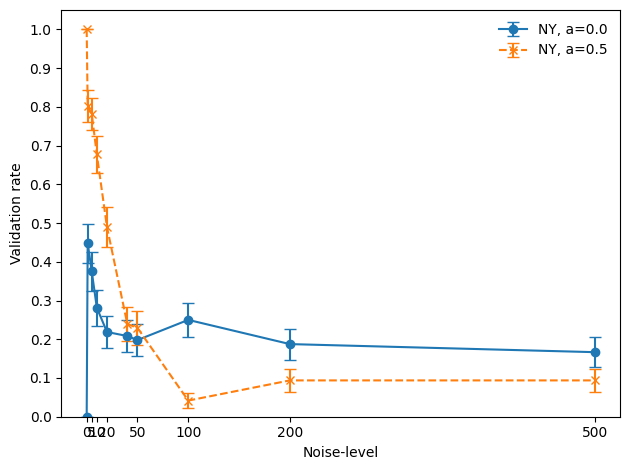

In [379]:
plt.errorbar(x=[0,1,5,10,20,40,50,100,200,500],y=simulated_two_qubit_NY_classical_accuracy,yerr=two_qubit_NY_classical_error,fmt='o-',capsize=4,barsabove=False,label="NY, a=0.0")

plt.errorbar(x=[0,1,5,10,20,40,50,100,200,500],y=simulated_two_qubit_NY_quantum_accuracy,yerr=two_qubit_NY_quantum_error,fmt='x--',capsize=4,barsabove=False,label="NY, a=0.5")

# plt.plot(0.0,.48,'ro',label="validation on quantum device",markersize=5)
plt.xlabel(r"Noise-level")
plt.legend(frameon=False)
# plt.grid()
plt.xticks([0,5,10,20,50,100,200,500])
plt.yticks(np.arange(0, 1.1, 0.1))
plt.ylim(0, 1.05)
plt.ylabel(r"Validation rate")
plt.tight_layout()

In [643]:
fig = plt.figure(figsize=(8, 6))


Num_pairs_a_0_Laser_ent = [0,1,5]
success_rate_a_0_Laser_ent = [27/96,48/96,11/96]
two_qubit_trapped_ion_error = binomial_error(np.array(success_rate_a_0_Laser_ent),96)


#plot 1: trapped-ion NY with laser entanglement

plt.errorbar(x=[0,1,5,10,20],
             y=simulated_two_qubit_NY_classical_accuracy[:5],
             yerr=simulated_two_qubit_NY_classical_error[:5],
             fmt='o-',capsize=4,barsabove=False,label="NY, a=0.0, (QASM Simulation)", color="coral")
plt.errorbar(x=[0,1,5,10,20],
             y=two_qubit_NY_classical_accuracy[:5],
             yerr=two_qubit_NY_classical_error[:5],
             fmt='o-',capsize=4,
             barsabove=False,
             label="NY, a=0.0, Superconducting",
             color="purple")
plt.errorbar(Num_pairs_a_0_Laser_ent, 
            success_rate_a_0_Laser_ent,
            yerr=two_qubit_trapped_ion_error,
            fmt='.--', capsize=4, label="NY, a=0.0 Trapped-Ion",color="skyblue")



# plt.errorbar(x=[0,1,5,10,20,40,50,100,200,500],y=simulated_two_qubit_NY_quantum_accuracy,
#              yerr=two_qubit_NY_quantum_error,fmt='x--',capsize=4,barsabove=False,label="NY, a=0.5")


plt.xticks([0,1,5,10,15,20])

plt.xlabel(r'Noise Level (\# $UU^\dagger$)',fontsize=22)
plt.ylabel("Validation rate",fontsize=22)
plt.xlim(0,22)
plt.ylim(0,.7)
plt.legend(frameon=False)


# Now add your inset:
ax = plt.gca()    # get the main axes

# read your image
img = plt.imread("/Users/dlakhdar/physics/copy_repos/natural-quantization/figures/NY_image.png")

# create a new axes whose rectangle [left, bottom, width, height] is in FRACTIONS of the main axes:
# here we choose it to span from 80%→95% in x and 60%→75% in y
inset_ax = plt.axes([0.3, 0.8, 0.15, 0.15], transform=ax.transAxes)

inset_ax.imshow(img, aspect='auto')
inset_ax.axis('off')

plt.tight_layout()
plt.show()


plt.savefig("two_qubit_noise.pdf", bbox_inches='tight', pad_inches=0.1)


/var/folders/04/2cqfhcv133s3gbkf3b35tnkr0000gn/T/ipykernel_80283/3320612672.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/04/2cqfhcv133s3gbkf3b35tnkr0000gn/T/ipykernel_80283/3320612672.py:56: UserWarning: FigureCanvasPgf is non-interactive, and thus cannot be shown
  plt.show()


In [507]:
two_qubit_NY_classical_accuracy

[np.float64(0.34375),
 np.float64(0.3125),
 np.float64(0.3125),
 np.float64(0.4166666666666667),
 np.float64(0.40625),
 np.float64(0.4895833333333333),
 np.float64(0.4895833333333333)]

In [419]:
two_qubit_NY_classical_error= binomial_error(np.array(two_qubit_NY_classical_accuracy),96)

In [422]:
simulated_two_qubit_NY_classical_error= binomial_error(np.array(simulated_two_qubit_NY_classical_accuracy),96)